# Lecture 7 · Dropout from scratch (inverted dropout)

**Goal** · implement inverted dropout, verify it is *unbiased* ($\mathbb{E}[\tilde h]=h$), reproduce the lecture's worked example, and see why nothing needs rescaling at test time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

## 1 · Inverted dropout

During training each unit is kept with probability $p$ and rescaled by $1/p$:

$$m_j\sim\mathrm{Bernoulli}(p),\qquad \tilde h = \frac{m\odot h}{p}.$$

At test time return $h$ unchanged.

In [2]:
def dropout(h, p, training, rng):
    if not training:
        return h                      # eval: identity
    m = (rng.random(h.shape) < p).astype(float)
    return m * h / p                  # inverted dropout

## 2 · Worked example

$h=[2,4,6,8]$, keep-prob $p=0.5$, mask $m=[1,0,1,0]$:

$$\tilde h = \frac{[1,0,1,0]\odot[2,4,6,8]}{0.5}=[4,0,12,0].$$

In [3]:
h = np.array([2., 4., 6., 8.])
m = np.array([1., 0., 1., 0.])
h_tilde = m * h / 0.5
print('h       =', h)
print('mask    =', m)
print('h_tilde =', h_tilde, '  <- matches [4, 0, 12, 0]')

h       = [2. 4. 6. 8.]
mask    = [1. 0. 1. 0.]
h_tilde = [ 4.  0. 12.  0.]   <- matches [4, 0, 12, 0]


## 3 · It is unbiased: $\mathbb{E}[\tilde h]=h$

Average the *random* dropout output over many masks; it converges to the original $h$.

In [4]:
trials = 200_000
acc = np.zeros_like(h)
for _ in range(trials):
    acc += dropout(h, 0.5, training=True, rng=rng)
mc_mean = acc / trials
print('Monte-Carlo E[h_tilde] =', np.round(mc_mean, 3))
print('original h             =', h)
print('eval-mode output       =', dropout(h, 0.5, training=False, rng=rng))

Monte-Carlo E[h_tilde] = [1.998 4.    6.013 8.   ]
original h             = [2. 4. 6. 8.]
eval-mode output       = [2. 4. 6. 8.]


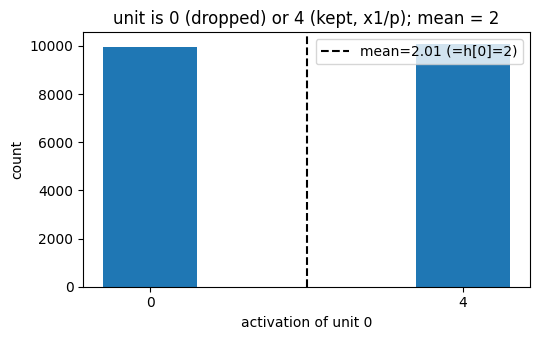

In [5]:
samples = np.array([dropout(h, 0.5, True, rng)[0] for _ in range(20000)])
plt.figure(figsize=(5.5, 3.5))
plt.hist(samples, bins=[-1, 1, 3, 5], rwidth=0.6)
plt.axvline(samples.mean(), color='k', ls='--', label=f'mean={samples.mean():.2f} (=h[0]=2)')
plt.xticks([0, 4]); plt.xlabel('activation of unit 0'); plt.ylabel('count')
plt.title('unit is 0 (dropped) or 4 (kept, x1/p); mean = 2'); plt.legend()
plt.tight_layout(); plt.show()

## Takeaway

- Inverted dropout multiplies kept units by $1/p$ so the expected activation is unchanged.
- Each mask trains a different *sub-network*; test time uses the full network with **no** rescaling.
- Mind the `training` flag: dropping units at eval time is a classic bug.